In [ ]:
import csv
import matplotlib.pyplot as plt
import numpy as np

DATA_PATH = "/Users/philipp/Downloads/experiments_jun_24.tsv"  # tab-separated despite the .csv extension



# --- read the data --------------------------------------------------------
rows = []            # (mean, Experiment, train_id)
exp_strategy = {}    # Experiment -> Pretrain Strategy (first seen)
with open(DATA_PATH, newline="") as f:
    reader = csv.DictReader(f, delimiter="\t")
    for r in reader:
        exp = r["Experiment"]
        rows.append((float(r["mean"]), exp, r["train_id"]))
        exp_strategy.setdefault(exp, r["Pretrain Strategy"])

# group rows by experiment, preserving first-seen order
order, groups = [], {}
for val, exp, tid in rows:
    if exp not in groups:
        groups[exp] = []
        order.append(exp)
    groups[exp].append((val, tid))

# derive category bands from the "Pretrain Strategy" column:
# consecutive experiments that share a strategy form one band
cats = []
start = 0
for i, exp in enumerate(order):
    last = i + 1 == len(order)
    if last or exp_strategy[order[i + 1]] != exp_strategy[exp]:
        label = exp_strategy[exp].replace(", ", ",\n", 1)  # wrap long labels
        cats.append((start, i, label))
        start = i + 1

positions = np.arange(1, len(order) + 1)
cmap = plt.cm.tab10(np.linspace(0, 1, len(order)))

fig, ax = plt.subplots(figsize=(14, 8))

# Manually allocate space at the top for brackets/title instead of using tight_layout
fig.subplots_adjust(top=0.82)

# boxplots (drawn first, behind the dots), alpha 0.5
data = [[v for v, _ in groups[e]] for e in order]
# bp = ax.boxplot(
#     data, positions=positions, widths=0.55, patch_artist=True, showfliers=False,
#     medianprops=dict(color="#1a1a1a", linewidth=1.4),
#     whiskerprops=dict(color="#666", linewidth=1.0),
#     capprops=dict(color="#666", linewidth=1.0),
#     boxprops=dict(linewidth=1.0, edgecolor="#444"),
#     zorder=1,
# )
# for patch, c in zip(bp["boxes"], cmap):
#     patch.set_facecolor(c)
#     patch.set_alpha(0.5)

# individual run means as aligned dots
for pos, exp, c in zip(positions, order, cmap):
    vals = [v for v, _ in groups[exp]]
    ax.scatter([pos] * len(vals), vals, s=55, color=c,
               edgecolor="#222", linewidth=0.7, zorder=3)

# --- category groupings ---------------------------------------------------
band_tints = ["#4C72B0", "#DD8452", "#55A868", "#8172B3"]
tr = ax.get_xaxis_transform()  # x in data coords, y in axes fraction
for j, (a, b, name) in enumerate(cats):
    tint = band_tints[j % len(band_tints)]
    xl, xr = positions[a] - 0.5, positions[b] + 0.5
    ax.axvspan(xl, xr, color=tint, alpha=0.06, zorder=0)
    cx = (positions[a] + positions[b]) / 2
    # bracket above the plot
    ax.plot([xl + 0.06, xr - 0.06], [1.045, 1.045], color="#555",
            lw=1.1, transform=tr, clip_on=False)
    ax.plot([xl + 0.06, xl + 0.06], [1.045, 1.02], color="#555",
            lw=1.1, transform=tr, clip_on=False)
    ax.plot([xr - 0.06, xr - 0.06], [1.045, 1.02], color="#555",
            lw=1.1, transform=tr, clip_on=False)
    ax.text(cx, 1.075, name, ha="center", va="bottom", fontsize=10.5,
            fontweight="bold", color="#333", transform=tr, clip_on=False)
# dotted separators between categories
for (_, b, _) in cats[:-1]:
    ax.axvline(positions[b] + 0.5, color="#bbb", lw=0.8, ls=":", zorder=0)

# axes cosmetics
ax.set_xticks(positions)
ax.set_xticklabels(order, rotation=35, ha="right", fontsize=10)
ax.set_xlim(0.5, len(order) + 0.7)
ax.set_ylim(0.5, 1)
ax.set_ylabel("mean", fontsize=12)
ax.set_title("Run means by experiment", fontsize=14, pad=64)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

# n= labels under each group
tr_bottom = ax.get_xaxis_transform()  # x is data coords, y is axes fraction (0=bottom, 1=top)
for pos, exp in zip(positions, order):
    ax.text(pos, 0.04, f"n={len(groups[exp])}", ha="center", va="top",
            fontsize=10, color="#666", transform=tr_bottom, clip_on=False)

# Saved without tight layout layout algorithms, but preserving elements outside bounding box
# fig.savefig("experiment_boxplots.png", dpi=200, bbox_inches="tight")
plt.show()

KeyError: 'mean'

In [26]:
DATA_PATH = "/Users/philipp/Downloads/experiments_jun_24.tsv"  # tab-separated despite the .csv extension

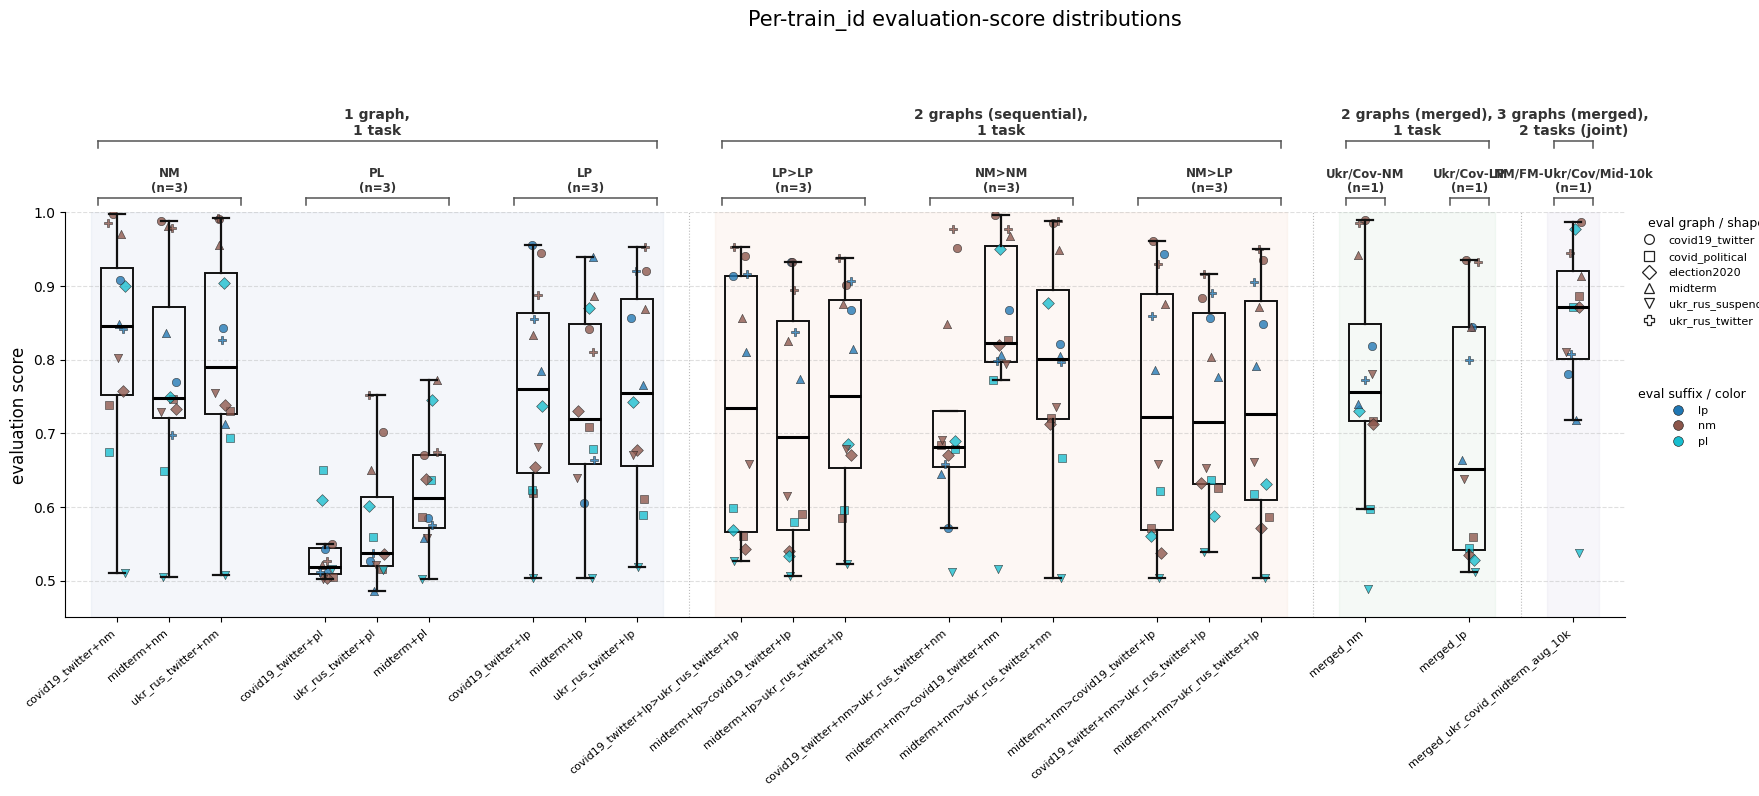

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# columns that are NOT per-dataset evaluation scores
META = ["train_id", "mean", "median", "Experiment", "Pretrain Strategy"]

# only these eval columns are used; all others are ignored
EVAL_COLS_RELEVANT = [
    "covid19_twitter+lp",
    "covid19_twitter+nm",
    "covid_political+nm",
    "covid_political+pl",
    "election2020+nm",
    "election2020+pl",
    "midterm+lp",
    "midterm+nm",
    "ukr_rus_suspended+nm",
    "ukr_rus_suspended+pl",
    "ukr_rus_twitter+lp",
    "ukr_rus_twitter+nm",
]

# --- read the data --------------------------------------------------------
df = pd.read_csv(DATA_PATH, sep="\t")

# keep only relevant eval columns that actually exist in the file
eval_cols = [c for c in EVAL_COLS_RELEVANT if c in df.columns]
missing_eval_cols = [c for c in EVAL_COLS_RELEVANT if c not in df.columns]

if missing_eval_cols:
    print("Warning: missing eval columns:", missing_eval_cols)

# Convert eval columns to numeric; bad/missing values become NaN
df[eval_cols] = df[eval_cols].apply(pd.to_numeric, errors="coerce")

order = df["Experiment"].drop_duplicates().tolist()

exp_strategy = (
    df.drop_duplicates("Experiment")
      .set_index("Experiment")["Pretrain Strategy"]
      .to_dict()
)

group_size = df.groupby("Experiment", sort=False).size().to_dict()

# --- parse eval column structure -----------------------------------------
# Example:
#   election2020+nm
#   graph = election2020  -> marker shape
#   mode  = nm            -> color

def split_eval_col(col):
    graph, mode = col.rsplit("+", 1)
    return graph, mode

eval_graphs = []
eval_modes = []

for col in eval_cols:
    graph, mode = split_eval_col(col)

    if graph not in eval_graphs:
        eval_graphs.append(graph)

    if mode not in eval_modes:
        eval_modes.append(mode)

# shapes are determined by the graph/dataset prefix
marker_cycle = [
    "o", "s", "D", "^", "v", "P", "X", "*",
    "<", ">", "h", "H", "p", "8"
]

graph_marker = {
    graph: marker_cycle[i % len(marker_cycle)]
    for i, graph in enumerate(eval_graphs)
}

# colors are determined by the suffix/mode
cmap = plt.colormaps["tab10"]
mode_color = {
    mode: cmap(i / max(1, len(eval_modes) - 1))
    for i, mode in enumerate(eval_modes)
}

# --- lay out one column per train_id, with a gap between experiments -------
GAP = 1.0

positions = []
box_data = []
box_exp = []
point_rows = []
tick_labels = []
exp_span = {}

x = 1.0
for e, g in df.groupby("Experiment", sort=False):
    xs = []

    for _, row in g.iterrows():
        scores = row[eval_cols].to_numpy(dtype=float)
        scores = scores[np.isfinite(scores)]  # remove NaN / inf

        positions.append(x)
        box_data.append(scores)
        box_exp.append(e)
        point_rows.append(row[eval_cols])
        tick_labels.append(row["train_id"])
        xs.append(x)

        x += 1.0

    exp_span[e] = (xs[0], xs[-1])
    x += GAP

positions = np.array(positions)

# --- figure ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(20, 9))
fig.subplots_adjust(left=0.05, right=0.83, top=0.77, bottom=0.32)

tr = ax.get_xaxis_transform()  # x in data coords, y in axes fraction

# --- strategy background bands -------------------------------------------
cats = []
start_i = 0

for i, e in enumerate(order):
    if i + 1 == len(order) or exp_strategy[order[i + 1]] != exp_strategy[e]:
        cats.append((start_i, i, exp_strategy[e]))
        start_i = i + 1

band_tints = ["#4C72B0", "#DD8452", "#55A868", "#8172B3"]

for j, (a, b, _) in enumerate(cats):
    xl = exp_span[order[a]][0] - 0.5
    xr = exp_span[order[b]][1] + 0.5
    ax.axvspan(
        xl,
        xr,
        color=band_tints[j % len(band_tints)],
        alpha=0.06,
        zorder=0,
    )

# --- per-train_id boxplots ------------------------------------------------
valid_idx = [i for i, scores in enumerate(box_data) if len(scores) > 0]

valid_box_data = [box_data[i] for i in valid_idx]
valid_positions = positions[valid_idx]

bp = ax.boxplot(
    valid_box_data,
    positions=valid_positions,
    widths=0.62,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="#000", linewidth=2.2),
    whiskerprops=dict(color="#111", linewidth=1.6),
    capprops=dict(color="#111", linewidth=1.6),
    boxprops=dict(linewidth=1.4, edgecolor="#111", facecolor="none"),
)

# neutral / uncolored boxplots
for patch in bp["boxes"]:
    patch.set_facecolor("none")
    patch.set_edgecolor("#111")
    patch.set_alpha(1.0)
    patch.set_zorder(3)

for key in ["medians", "whiskers", "caps"]:
    for artist in bp[key]:
        artist.set_zorder(7)
        artist.set_alpha(1.0)

# --- overlay individual eval scores --------------------------------------
rng = np.random.default_rng(0)

for pos, row_scores in zip(positions, point_rows):
    for col in eval_cols:
        score = row_scores[col]

        if not np.isfinite(score):
            continue

        graph, mode = split_eval_col(col)

        jx = pos + (rng.random() - 0.5) * 0.34

        ax.scatter(
            jx,
            score,
            s=36,
            marker=graph_marker[graph],
            color=mode_color[mode],
            edgecolor="#222",
            linewidth=0.45,
            alpha=0.78,
            zorder=4,
        )

# Re-lift boxplot lines above scatter
for key in ["medians", "whiskers", "caps"]:
    for artist in bp[key]:
        artist.set_zorder(7)

# --- legends --------------------------------------------------------------
# Shape legend: graph/dataset prefix
shape_handles = [
    Line2D(
        [0],
        [0],
        marker=graph_marker[graph],
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="#222",
        markeredgewidth=0.9,
        markersize=7,
        label=graph,
    )
    for graph in eval_graphs
]

shape_legend = ax.legend(
    handles=shape_handles,
    title="eval graph / shape",
    loc="upper left",
    bbox_to_anchor=(1.005, 1.0),
    borderaxespad=0.0,
    frameon=False,
    fontsize=8,
    title_fontsize=9,
)

ax.add_artist(shape_legend)

# Color legend: suffix/mode
color_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=mode_color[mode],
        markeredgecolor="#222",
        markeredgewidth=0.45,
        markersize=7,
        label=mode,
    )
    for mode in eval_modes
]

ax.legend(
    handles=color_handles,
    title="eval suffix / color",
    loc="upper left",
    bbox_to_anchor=(1.005, 0.58),
    borderaxespad=0.0,
    frameon=False,
    fontsize=8,
    title_fontsize=9,
)

# --- brackets -------------------------------------------------------------
def bracket(xl, xr, y_bar, label, fontsize):
    pad = 0.12

    ax.plot(
        [xl + pad, xr - pad],
        [y_bar, y_bar],
        color="#555",
        lw=1.1,
        transform=tr,
        clip_on=False,
    )

    for xt in (xl + pad, xr - pad):
        ax.plot(
            [xt, xt],
            [y_bar, y_bar - 0.016],
            color="#555",
            lw=1.1,
            transform=tr,
            clip_on=False,
        )

    ax.text(
        (xl + xr) / 2,
        y_bar + 0.008,
        label,
        ha="center",
        va="bottom",
        fontsize=fontsize,
        fontweight="bold",
        color="#333",
        transform=tr,
        clip_on=False,
    )


# inner brackets: experiment groups
for e in order:
    a, b = exp_span[e]
    bracket(a - 0.5, b + 0.5, 1.035, f"{e}\n(n={group_size[e]})", 8.5)

# outer brackets: pretrain-strategy categories
for a, b, name in cats:
    xl = exp_span[order[a]][0] - 0.5
    xr = exp_span[order[b]][1] + 0.5
    bracket(xl, xr, 1.175, name.replace(", ", ",\n", 1), 10)

# dotted separators between strategy categories
for _, b, _ in cats[:-1]:
    ax.axvline(
        exp_span[order[b]][1] + 0.5 + GAP / 2,
        color="#bbb",
        lw=0.8,
        ls=":",
        zorder=0,
    )

# --- axes cosmetics -------------------------------------------------------
ax.set_xticks(positions)
ax.set_xticklabels(tick_labels, rotation=40, ha="right", fontsize=8)

ax.set_xlim(positions[0] - 1.0, positions[-1] + 1.0)
ax.set_ylim(0.45, 1.0)

ax.set_ylabel("evaluation score", fontsize=12)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Per-train_id evaluation-score distributions", fontsize=15, y=0.995)

# fig.savefig("trainid_boxplots.png", dpi=200, bbox_inches="tight")
plt.show()

In [34]:
df = df.set_index("train_id")

In [38]:
df.loc[['covid19_twitter+nm', 'covid19_twitter+nm>ukr_rus_twitter+nm']]

,covid19_twitter+lp,covid19_twitter+nm,covid_political+nm,covid_political+pl,election2020+nm,election2020+pl,midterm+lp,midterm+nm,ukr_rus_suspended+nm,ukr_rus_suspended+pl,ukr_rus_twitter+lp,ukr_rus_twitter+nm,Experiment,Pretrain Strategy
train_id,,,,,,,,,,,,,,
covid19_twitter+nm,0.908,0.998,0.738,0.674,0.757,0.900,0.849,0.971,0.802,0.510,0.842,0.986,NM,"1 graph, 1 task"
covid19_twitter+nm>ukr_rus_twitter+nm,0.572,0.952,0.684,0.678,0.671,0.689,0.644,0.849,0.691,0.511,0.658,0.978,NM>NM,"2 graphs (sequential), 1 task"


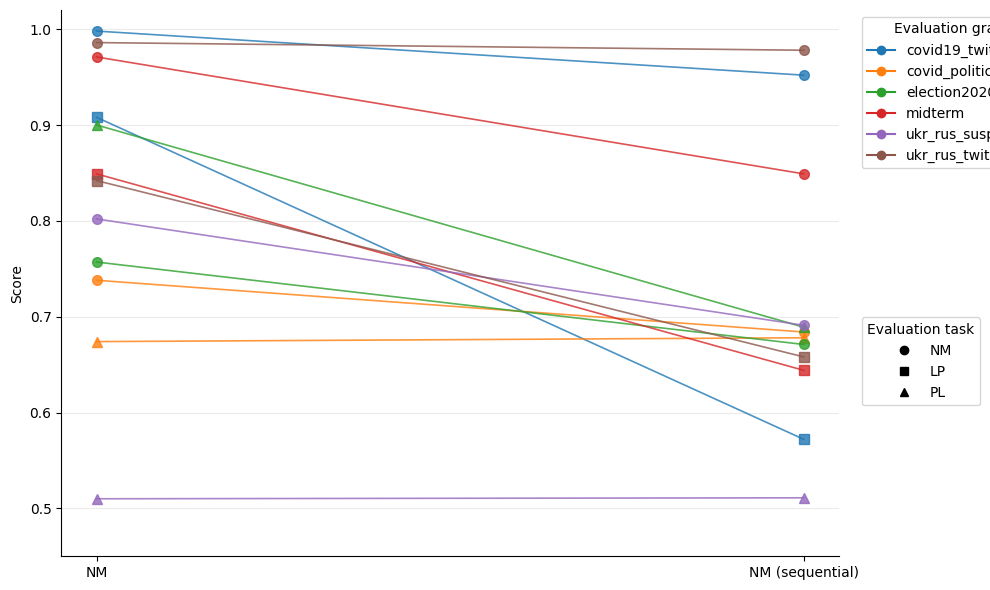

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

train_rows = [
    "covid19_twitter+nm",
    "covid19_twitter+nm>ukr_rus_twitter+nm",
]

eval_cols = df.columns[:12]
plot_df = df.loc[train_rows, eval_cols].T.reset_index(
    names="eval_dataset"
)

# Extract evaluation graph and task from column names
plot_df[["graph", "task"]] = plot_df["eval_dataset"].str.rsplit(
    "+", n=1, expand=True
)

x_labels = ["NM", "NM (sequential)"]
markers = {"nm": "o", "lp": "s", "pl": "^"}
colors = dict(
    zip(
        plot_df["graph"].unique(),
        sns.color_palette("tab10", plot_df["graph"].nunique()),
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

# Each evaluation dataset/task gets one connected line
for _, row in plot_df.iterrows():
    scores = row[train_rows].astype(float).to_numpy()

    ax.plot(
        range(2),
        scores,
        color=colors[row["graph"]],
        marker=markers[row["task"]],
        linewidth=1.2,
        markersize=7,
        alpha=0.8,
    )

ax.set_xticks(range(2), x_labels)
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0.45, 1.02)
ax.grid(axis="y", alpha=0.25)

# Separate legends for graph/color and task/shape
graph_handles = [
    Line2D([0], [0], color=color, marker="o", linestyle="-", label=graph)
    for graph, color in colors.items()
]
task_handles = [
    Line2D(
        [0], [0],
        color="black",
        marker=marker,
        linestyle="None",
        label=task.upper(),
    )
    for task, marker in markers.items()
]

graph_legend = ax.legend(
    handles=graph_handles,
    title="Evaluation graph",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
ax.add_artist(graph_legend)

ax.legend(
    handles=task_handles,
    title="Evaluation task",
    bbox_to_anchor=(1.02, 0.45),
    loc="upper left",
)

sns.despine()
fig.tight_layout()
plt.show()

In [ ]:
eval_cols = df.columns[:12]

records = {}

for treatment in df.index[df["Experiment"].isin(["NM>NM", "LP>LP"])]:
    baseline = treatment.split(">")[0]

    records[(baseline, treatment)] = (
        df.loc[treatment, eval_cols].astype(float)
        - df.loc[baseline, eval_cols].astype(float)
    )

delta_df = pd.DataFrame(records).T
delta_df.index = pd.MultiIndex.from_tuples(
    delta_df.index,
    names=["baseline", "treatment"],
)

delta_df.round(3).mean(1)

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_72080/3074564610.py:19: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  delta_df.round(3).mean(1)


baseline            treatment                            
covid19_twitter+lp  covid19_twitter+lp>ukr_rus_twitter+lp   -0.019417
midterm+lp          midterm+lp>covid19_twitter+lp           -0.026083
                    midterm+lp>ukr_rus_twitter+lp            0.014083
covid19_twitter+nm  covid19_twitter+nm>ukr_rus_twitter+nm   -0.113167
midterm+nm          midterm+nm>covid19_twitter+nm            0.060750
                    midterm+nm>ukr_rus_twitter+nm            0.016500
dtype: float64

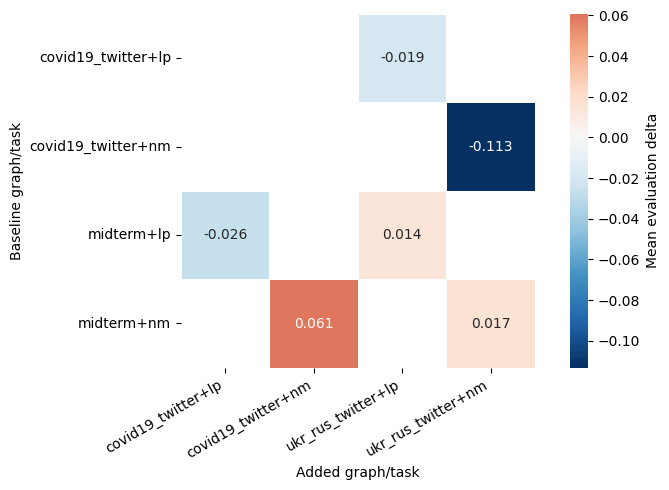

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

mean_delta = delta_df.mean(axis=1).rename("mean_delta").reset_index()

# Extract the graph/task added during sequential training
mean_delta["added"] = mean_delta["treatment"].str.split(">").str[-1]

matrix = mean_delta.pivot(
    index="baseline",
    columns="added",
    values="mean_delta",
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    matrix,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Mean evaluation delta"},
    ax=ax,
)

ax.set_xlabel("Added graph/task")
ax.set_ylabel("Baseline graph/task")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()